In [ ]:
!python3 --version


Python 3.12.13


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load the MNIST dataset (handwritten digits)
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


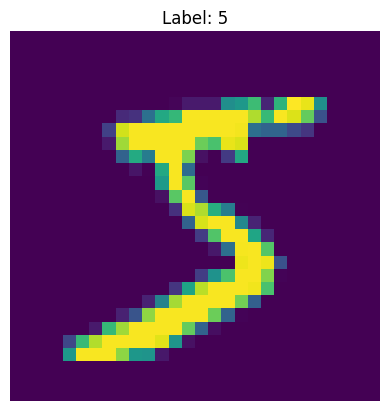

In [ ]:
import matplotlib.pyplot as plt

# Pick an index (0 to 59,999)
index = 0

# Show the image
plt.imshow(x_train[index]   )
plt.title(f"Label: {y_train[index]}")
plt.axis('off') # Hide the x and y numbers
plt.show()

In [ ]:
# Scale pixels to a range of 0 to 1
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
model = models.Sequential([
    # 1. Flatten: Turns the 28x28 pixel grid into a long 1D line of 784 pixels
    layers.Flatten(input_shape=(28, 28)),

    # 2. Dense Layer: A layer of 128 "neurons" that look for patterns
    layers.Dense(128, activation='relu'),

    # 3. Dropout: Randomly turns off some neurons to prevent "memorizing" (overfitting)
    layers.Dropout(0.2),

    # 4. Output Layer: 10 neurons representing digits 0 through 9
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9160 - loss: 0.2919
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9571 - loss: 0.1442
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9681 - loss: 0.1059
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9728 - loss: 0.0887
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9765 - loss: 0.0758


In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0693


[0.06925834715366364, 0.9781000018119812]

In [ ]:
model.save('mnist_model.keras')

from google.colab import files
files.download('mnist_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>